# 1. Imports and Setup

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Set seed for reproducibility
np.random.seed(17)

# 2. Data Loading

In [2]:
prices = pd.read_csv("prices_2025.csv")
stations = pd.read_csv("stations_2025.csv")

# 3. Initial Data Inspection

In [3]:
print("Prices shape:", prices.shape)
print("Stations shape:", stations.shape)

display(prices.head())
display(stations.head())

Prices shape: (5302458, 5)
Stations shape: (14420, 10)


,Station ID,Fuel ID,Fuel,Date,Price
0,1000001,1.0,Gazole,2025-01-02T00:37:00,1.707
1,1000001,1.0,Gazole,2025-01-02T07:56:00,1.707
2,1000001,1.0,Gazole,2025-01-03T00:38:00,1.725
3,1000001,1.0,Gazole,2025-01-07T00:37:00,1.705
4,1000001,1.0,Gazole,2025-01-09T00:37:00,1.688


,Station ID,Postal Code,Location Type,Latitude Raw,Longitude Raw,Latitude,Longitude,Address,City,24/7 Payment Terminal
0,1000001,1000,R,4.620100e+06,519800.000000,46.201000,5.19800,596 AVENUE DE TREVOUX,SAINT-DENIS-LèS-BOURG,NaN
1,1000002,1000,R,4.621842e+06,522767.000000,46.218420,5.22767,16 Avenue de Marboz,BOURG-EN-BRESSE,NaN
2,1000004,1000,R,4.618800e+06,524500.000000,46.188000,5.24500,20 Avenue du Maréchal Juin,Bourg-en-Bresse,1.0
3,1000005,1000,R,4.620094e+06,519942.024022,46.200936,5.19942,642 Avenue de Trévoux,SAINT-DENIS-LèS-BOURG,NaN
4,1000006,1000,R,4.620754e+06,523758.000000,46.207540,5.23758,1 Boulevard John Kennedy,BOURG-EN-BRESSE,NaN


In [4]:
prices.info()
stations.info()

print("\nMissing values - PRICES")
display(prices.isna().sum())

print("\nMissing values - STATIONS")
display(stations.isna().sum())

print("\nFuel types")
display(prices["Fuel"].value_counts(dropna=False))

print("\nLocation types")
display(stations["Location Type"].value_counts(dropna=False))

print("\n24/7 Payment Terminal")
display(stations["24/7 Payment Terminal"].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 5302458 entries, 0 to 5302457
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Station ID  int64  
 1   Fuel ID     float64
 2   Fuel        str    
 3   Date        str    
 4   Price       float64
dtypes: float64(2), int64(1), str(2)
memory usage: 202.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 14420 entries, 0 to 14419
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Station ID             14420 non-null  int64  
 1   Postal Code            14420 non-null  int64  
 2   Location Type          14420 non-null  str    
 3   Latitude Raw           14351 non-null  float64
 4   Longitude Raw          14352 non-null  float64
 5   Latitude               14351 non-null  float64
 6   Longitude              14352 non-null  float64
 7   Address                14420 non-null  str    
 8   City                   14420 non-null  st

Station ID       0
Fuel ID       4658
Fuel          4658
Date          4658
Price         4658
dtype: int64


Missing values - STATIONS


Station ID                  0
Postal Code                 0
Location Type               0
Latitude Raw               69
Longitude Raw              68
Latitude                   69
Longitude                  68
Address                     0
City                        0
24/7 Payment Terminal    8462
dtype: int64


Fuel types


Fuel
Gazole    1520477
E10       1351304
SP98      1291207
E85        581219
SP95       281659
GPLc       271934
NaN          4658
Name: count, dtype: int64


Location types


Location Type
R    13562
A      857
N        1
Name: count, dtype: int64


24/7 Payment Terminal


24/7 Payment Terminal
NaN    8462
1.0    5958
Name: count, dtype: int64

In [5]:
stations[stations["Location Type"] == "N"]

,Station ID,Postal Code,Location Type,Latitude Raw,Longitude Raw,Latitude,Longitude,Address,City,24/7 Payment Terminal
1655,13500010,13500,N,4339948.0,506223.0,43.39948,5.06223,Rond-Point Sainte-Anne,Martigues,NaN


In [6]:
display(prices[prices["Fuel"].isna()].head(10))

prices[prices["Fuel"].isna()]["Station ID"].nunique()

,Station ID,Fuel ID,Fuel,Date,Price
1554,1000005,NaN,NaN,NaN,NaN
1555,1000006,NaN,NaN,NaN,NaN
4492,1000010,NaN,NaN,NaN,NaN
7243,1100001,NaN,NaN,NaN,NaN
7429,1100003,NaN,NaN,NaN,NaN
10750,1120002,NaN,NaN,NaN,NaN
10751,1120003,NaN,NaN,NaN,NaN
14218,1130001,NaN,NaN,NaN,NaN
17314,1160001,NaN,NaN,NaN,NaN
21980,1200004,NaN,NaN,NaN,NaN


4658

# 4. Data Cleaning

In [7]:
# Remove records with no fuel type, date, or price because they cannot be used for price analysis
prices = prices.dropna(subset=["Fuel", "Date", "Price"]).copy()

prices.shape

(5297800, 5)

In [8]:
# Convert postal codes to 5-character strings to preserve leading zeros
stations["Postal Code"] = stations["Postal Code"].astype(str).str.zfill(5)

# Convert the Date column from string to datetime for time-based analysis
prices["Date"] = pd.to_datetime(prices["Date"])

In [9]:
# Check the converted data types and the time period covered by the dataset
print(prices["Date"].dtype)
print(stations["Postal Code"].dtype)

print("Start date:", prices["Date"].min())
print("End date:", prices["Date"].max())

display(stations["Postal Code"].head())

datetime64[us]
str
Start date: 2025-01-01 00:00:00
End date: 2025-12-31 23:59:00


0    01000
1    01000
2    01000
3    01000
4    01000
Name: Postal Code, dtype: str

In [10]:
# Check for exact duplicate price records
duplicate_prices = prices.duplicated().sum()

# Check for exact duplicate station records
duplicate_stations = stations.duplicated().sum()

print("Duplicate price rows:", duplicate_prices)
print("Duplicate station rows:", duplicate_stations)

Duplicate price rows: 0
Duplicate station rows: 0


In [11]:
# Check whether the same station and fuel have multiple records at the exact same datetime
duplicate_price_keys = prices.duplicated(
    subset=["Station ID", "Fuel", "Date"]
).sum()

print("Duplicate station-fuel-date combinations:", duplicate_price_keys)

Duplicate station-fuel-date combinations: 1


In [12]:
# Display the duplicated station-fuel-date records to inspect the conflicting values
duplicate_mask = prices.duplicated(
    subset=["Station ID", "Fuel", "Date"],
    keep=False
)

prices[duplicate_mask].sort_values(
    by=["Station ID", "Fuel", "Date"]
)

,Station ID,Fuel ID,Fuel,Date,Price
940523,24650001,5.0,E10,2025-09-05 08:33:38,1.560
940524,24650001,5.0,E10,2025-09-05 08:33:38,1.566


In [13]:
# Inspect surrounding E10 price observations for the conflicting record
station_history = prices[
    (prices["Station ID"] == 24650001) &
    (prices["Fuel"] == "E10")
].sort_values("Date")

conflict_time = pd.Timestamp("2025-09-05 08:33:38")

# Display observations around the conflicting datetime
display(
    station_history[
        (station_history["Date"] >= conflict_time - pd.Timedelta(days=7)) &
        (station_history["Date"] <= conflict_time + pd.Timedelta(days=7))
    ]
)

,Station ID,Fuel ID,Fuel,Date,Price
940512,24650001,5.0,E10,2025-08-29 11:13:49,1.615
940513,24650001,5.0,E10,2025-09-01 14:05:20,1.610
940514,24650001,5.0,E10,2025-09-01 14:06:18,1.615
940515,24650001,5.0,E10,2025-09-02 10:33:06,1.623
940516,24650001,5.0,E10,2025-09-03 12:30:57,1.629
940517,24650001,5.0,E10,2025-09-05 08:33:12,1.566
940518,24650001,5.0,E10,2025-09-05 08:33:22,1.566
940519,24650001,5.0,E10,2025-09-05 08:33:27,1.566
940520,24650001,5.0,E10,2025-09-05 08:33:31,1.566
940521,24650001,5.0,E10,2025-09-05 08:33:33,1.566


In [14]:
# Remove the single inconsistent price record identified through temporal inspection
prices = prices.drop(
    prices[
        (prices["Station ID"] == 24650001) &
        (prices["Fuel"] == "E10") &
        (prices["Date"] == "2025-09-05 08:33:38") &
        (prices["Price"] == 1.560)
    ].index
).copy()

# Verify that no duplicate station-fuel-date combinations remain
print(
    "Remaining duplicate station-fuel-date combinations:",
    prices.duplicated(subset=["Station ID", "Fuel", "Date"]).sum()
)

print("Prices shape:", prices.shape)

Remaining duplicate station-fuel-date combinations: 0
Prices shape: (5297799, 5)


In [15]:
# Explore the overall distribution of fuel prices before defining any outlier rule
display(prices["Price"].describe())

# Inspect the lowest and highest recorded prices
print("Minimum price:", prices["Price"].min())
print("Maximum price:", prices["Price"].max())

# Check price distribution by fuel type
display(
    prices.groupby("Fuel")["Price"]
    .describe()
    .round(3)
)

count    5.297799e+06
mean     1.579555e+00
std      3.469259e-01
min      3.850000e-01
25%      1.588000e+00
50%      1.686000e+00
75%      1.769000e+00
max      3.000000e+00
Name: Price, dtype: float64

Minimum price: 0.385
Maximum price: 3.0


,count,mean,std,min,25%,50%,75%,max
Fuel,,,,,,,,
E10,1351303.0,1.713,0.092,1.261,1.649,1.699,1.761,2.664
E85,581219.0,0.764,0.086,0.385,0.709,0.749,0.792,1.999
GPLc,271934.0,0.992,0.080,0.496,0.939,0.985,1.049,1.989
Gazole,1520477.0,1.648,0.098,1.213,1.579,1.636,1.701,3.000
SP95,281659.0,1.727,0.067,1.326,1.684,1.717,1.769,2.889
SP98,1291207.0,1.817,0.103,1.296,1.741,1.796,1.879,2.997


In [16]:
# Display the 10 lowest recorded fuel prices
display(
    prices.nsmallest(10, "Price")
)

# Display the 10 highest recorded fuel prices
display(
    prices.nlargest(10, "Price")
)

,Station ID,Fuel ID,Fuel,Date,Price
733666,17690001,3.0,E85,2025-09-25 08:47:17,0.385
1616022,34700001,3.0,E85,2025-05-16 09:18:21,0.397
3672353,71100002,3.0,E85,2025-02-10 14:51:00,0.427
3672354,71100002,3.0,E85,2025-02-10 22:46:00,0.427
3672355,71100002,3.0,E85,2025-02-11 07:56:00,0.428
3672356,71100002,3.0,E85,2025-02-11 22:41:00,0.428
3672357,71100002,3.0,E85,2025-02-12 22:41:00,0.428
1975816,41000007,3.0,E85,2025-10-17 08:58:00,0.460
3619564,69571001,3.0,E85,2025-09-04 08:27:45,0.464
3344789,67114001,3.0,E85,2025-07-19 09:40:44,0.469


,Station ID,Fuel ID,Fuel,Date,Price
4785590,90150001,1.0,Gazole,2025-06-04 18:41:05,3.000
5259300,95470004,6.0,SP98,2025-03-16 15:29:18,2.997
3203970,63700007,6.0,SP98,2025-11-06 08:05:42,2.899
2733249,57210001,6.0,SP98,2025-06-24 08:55:02,2.895
1554506,34110004,2.0,SP95,2025-01-25 08:13:01,2.889
3660477,70300009,6.0,SP98,2025-02-20 09:56:28,2.889
398193,12100002,6.0,SP98,2025-11-13 08:02:07,2.859
398194,12100002,6.0,SP98,2025-11-13 08:02:08,2.859
398189,12100002,6.0,SP98,2025-10-28 07:32:10,2.846
4384422,81250006,2.0,SP95,2025-07-07 21:40:42,2.803


In [17]:
# Inspect diesel prices around the unusually high €3.00 observation
diesel_outlier_history = prices[
    (prices["Station ID"] == 90150001) &
    (prices["Fuel"] == "Gazole")
].sort_values("Date")

outlier_time = pd.Timestamp("2025-06-04 18:41:05")

display(
    diesel_outlier_history[
        (diesel_outlier_history["Date"] >= outlier_time - pd.Timedelta(days=7)) &
        (diesel_outlier_history["Date"] <= outlier_time + pd.Timedelta(days=7))
    ]
)

,Station ID,Fuel ID,Fuel,Date,Price
4785587,90150001,1.0,Gazole,2025-05-30 06:26:21,1.629
4785588,90150001,1.0,Gazole,2025-05-30 18:43:21,1.629
4785589,90150001,1.0,Gazole,2025-06-03 18:52:53,1.625
4785590,90150001,1.0,Gazole,2025-06-04 18:41:05,3.000
4785591,90150001,1.0,Gazole,2025-06-05 18:34:09,1.625
4785592,90150001,1.0,Gazole,2025-06-06 18:32:49,1.622
4785593,90150001,1.0,Gazole,2025-06-10 18:23:24,1.629


In [18]:
# Compare the suspicious diesel price with all diesel prices recorded on the same day
diesel_june_4 = prices[
    (prices["Fuel"] == "Gazole") &
    (prices["Date"].dt.date == pd.Timestamp("2025-06-04").date())
]

display(diesel_june_4["Price"].describe())

# Display the highest diesel prices recorded on that day
display(
    diesel_june_4.nlargest(20, "Price")[
        ["Station ID", "Date", "Price"]
    ]
)

count    3829.000000
mean        1.577122
std         0.085008
min         1.449000
25%         1.517000
50%         1.549000
75%         1.622000
max         3.000000
Name: Price, dtype: float64

,Station ID,Date,Price
4785590,90150001,2025-06-04 18:41:05,3.000
3783862,73140008,2025-06-04 00:01:00,1.929
2374369,49480005,2025-06-04 22:13:12,1.909
3789350,73190002,2025-06-04 22:12:12,1.909
3815486,73800001,2025-06-04 22:05:54,1.909
4044292,77140010,2025-06-04 09:30:00,1.901
4046936,77140012,2025-06-04 09:30:00,1.901
33906,1390009,2025-06-04 21:59:00,1.899
37178,1430003,2025-06-04 08:00:00,1.899
763972,18500006,2025-06-04 08:00:00,1.899


In [19]:
# Remove the isolated €3.00 diesel observation identified as an anomalous record
# based on both the station's temporal history and same-day national prices
prices = prices.drop(
    prices[
        (prices["Station ID"] == 90150001) &
        (prices["Fuel"] == "Gazole") &
        (prices["Date"] == "2025-06-04 18:41:05") &
        (prices["Price"] == 3.000)
    ].index
).copy()

print("Prices shape:", prices.shape)

Prices shape: (5297798, 5)


In [20]:
# Final check for missing values in the cleaned price dataset
display(
    prices.isna()
    .sum()
    .to_frame(name="Missing Values")
)

# Check missing values in the station dataset before deciding how to handle them
display(
    stations.isna()
    .sum()
    .to_frame(name="Missing Values")
)

,Missing Values
Station ID,0
Fuel ID,0
Fuel,0
Date,0
Price,0


,Missing Values
Station ID,0
Postal Code,0
Location Type,0
Latitude Raw,69
Longitude Raw,68
Latitude,69
Longitude,68
Address,0
City,0
24/7 Payment Terminal,8462


In [21]:
# 4.5 Inspect station-specific missing values

# Check the values used for the 24/7 payment terminal variable
display(
    stations["24/7 Payment Terminal"]
    .value_counts(dropna=False)
)

# Inspect stations with missing geographic coordinates
display(
    stations[
        stations["Latitude"].isna() |
        stations["Longitude"].isna()
    ].head(10)
)

24/7 Payment Terminal
NaN    8462
1.0    5958
Name: count, dtype: int64

,Station ID,Postal Code,Location Type,Latitude Raw,Longitude Raw,Latitude,Longitude,Address,City,24/7 Payment Terminal
46,1200004,01200,R,NaN,NaN,NaN,NaN,79 RUE DE LA REPUBLIQUE,BELLEGARDE,NaN
169,2100014,02100,R,NaN,NaN,NaN,NaN,60 BIS RUE DE LA FERE,SAINT QUENTIN,NaN
425,4210001,04210,R,NaN,NaN,NaN,NaN,6 rd MANOSQUE,VALENSOLE,NaN
530,6000012,06000,R,NaN,NaN,NaN,NaN,"26,28 QUAI GALLIENI",NICE,NaN
1009,10000017,10000,R,NaN,NaN,NaN,NaN,40 AV CHOMEDEY DE MAISONNEUVE,TROYES,NaN
1177,11400003,11400,R,NaN,NaN,NaN,NaN,RELAIS ST.MARTIN,SAINT-MARTIN-LALANDE,NaN
1763,13800008,13800,R,NaN,NaN,NaN,NaN,Avenue Félix Gouin,ISTRES,NaN
1965,15000015,15000,R,NaN,NaN,NaN,NaN,"Guerguet, Route de Sansac",AURILLAC,NaN
2011,15500004,15500,R,NaN,NaN,NaN,NaN,63 avenue du Général de Gaulle,MASSIAC,NaN
2460,20137001,20137,R,NaN,NaN,NaN,NaN,Station St Cyprien - Lecci,PORTO-VECCHIO,NaN


In [22]:
# The source encodes the 24/7 payment terminal as 1 when available
# and leaves the field empty when the service is not available.
# Therefore, missing values represent "No" and can safely be converted to 0.
# Final encoding: 1 = available, 0 = not available.

stations["24/7 Payment Terminal"] = (
    stations["24/7 Payment Terminal"]
    .fillna(0)
    .astype(int)
)

# Verify the conversion
print(stations["24/7 Payment Terminal"].value_counts())

24/7 Payment Terminal
0    8462
1    5958
Name: count, dtype: int64


# 5. Exploratory Data Analysis (EDA)

## 5.1 Fuel Price Distribution

In [23]:
# Summarize the price distribution for each fuel type
fuel_price_summary = (
    prices.groupby("Fuel")["Price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

display(fuel_price_summary)

,count,mean,median,std,min,max
Fuel,,,,,,
E10,1351303,1.713,1.699,0.092,1.261,2.664
E85,581219,0.764,0.749,0.086,0.385,1.999
GPLc,271934,0.992,0.985,0.080,0.496,1.989
Gazole,1520476,1.648,1.636,0.098,1.213,2.703
SP95,281659,1.727,1.717,0.067,1.326,2.889
SP98,1291207,1.817,1.796,0.103,1.296,2.997


### Key observations

Fuel prices show clear differences across fuel types in 2025. SP98 has the highest median price (€1.796/L), followed by SP95 (€1.717/L) and E10 (€1.699/L). Diesel (Gazole), which will be the main target of this project, has a median price of €1.636/L.

E85 and GPLc are substantially cheaper, with median prices of €0.749/L and €0.985/L respectively.

For most fuels, the mean and median prices are relatively close, suggesting that extreme observations do not strongly influence the overall price distribution. Diesel shows a standard deviation of €0.098/L, indicating meaningful price variation during the year and supporting further investigation of its temporal and geographical drivers.

## 5.2 Fuel Price Evolution Over Time

In [24]:
# Calculate the national daily median price for each fuel type
# The median is used to reduce the influence of unusually high or low station prices
daily_fuel_prices = (
    prices
    .assign(Day=prices["Date"].dt.date)
    .groupby(["Day", "Fuel"])["Price"]
    .median()
    .reset_index()
)

display(daily_fuel_prices.head(12))

,Day,Fuel,Price
0,2025-01-01,E10,1.749
1,2025-01-01,E85,0.789
2,2025-01-01,GPLc,0.999
3,2025-01-01,Gazole,1.693
4,2025-01-01,SP95,1.768
5,2025-01-01,SP98,1.859
6,2025-01-02,E10,1.729
7,2025-01-02,E85,0.776
8,2025-01-02,GPLc,0.993
9,2025-01-02,Gazole,1.658


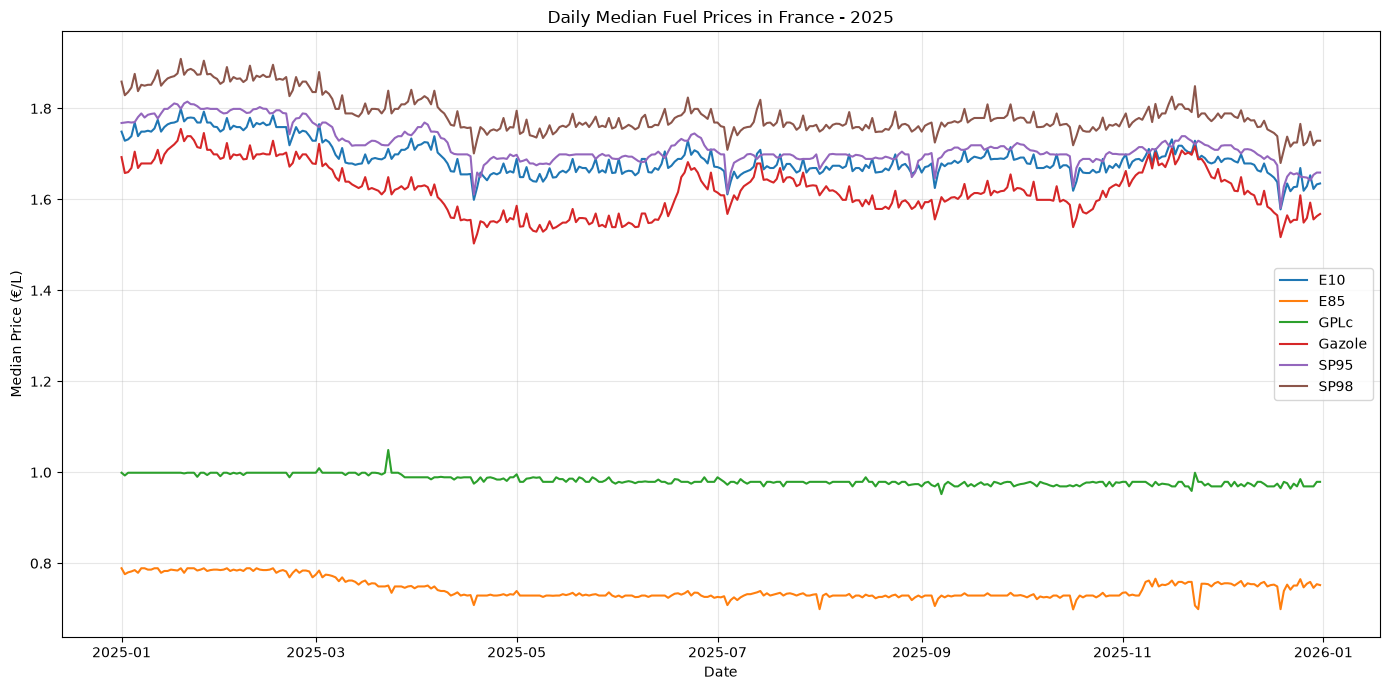

In [25]:
# Plot the daily median price evolution for each fuel type
plt.figure(figsize=(14, 7))

for fuel in daily_fuel_prices["Fuel"].unique():
    fuel_data = daily_fuel_prices[daily_fuel_prices["Fuel"] == fuel]
    plt.plot(
        fuel_data["Day"],
        fuel_data["Price"],
        label=fuel
    )

plt.title("Daily Median Fuel Prices in France - 2025")
plt.xlabel("Date")
plt.ylabel("Median Price (€/L)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Key observations

Fuel prices show clear temporal patterns throughout 2025. Diesel (Gazole), E10, SP95 and SP98 appear to follow broadly similar movements, with common periods of decline and increase during the year.

Diesel shows more pronounced fluctuations during some periods, while E85 and GPLc remain comparatively stable and evolve at substantially lower price levels.

The similar temporal movements observed between diesel and several gasoline fuels suggest that they may share common market dynamics. This relationship will be investigated further through correlation analysis.

## 5.3 Correlation Between Fuel Prices

In [26]:
# Reshape daily fuel prices to compare fuel types on the same dates
daily_fuel_pivot = daily_fuel_prices.pivot(
    index="Day",
    columns="Fuel",
    values="Price"
)

display(daily_fuel_pivot.head())

Fuel,E10,E85,GPLc,Gazole,SP95,SP98
Day,,,,,,
2025-01-01,1.749,0.789,0.999,1.693,1.768,1.859
2025-01-02,1.729,0.776,0.993,1.658,1.769,1.829
2025-01-03,1.732,0.780,0.999,1.660,1.770,1.836
2025-01-04,1.739,0.782,0.999,1.669,1.769,1.846
2025-01-05,1.769,0.785,0.999,1.705,1.770,1.876


In [27]:
# Calculate correlations between daily median fuel prices
fuel_correlation = daily_fuel_pivot.corr().round(2)

display(fuel_correlation)

Fuel,E10,E85,GPLc,Gazole,SP95,SP98
Fuel,,,,,,
E10,1.00,0.82,0.64,0.87,0.94,0.99
E85,0.82,1.00,0.64,0.74,0.82,0.85
GPLc,0.64,0.64,1.00,0.44,0.67,0.71
Gazole,0.87,0.74,0.44,1.00,0.80,0.85
SP95,0.94,0.82,0.67,0.80,1.00,0.94
SP98,0.99,0.85,0.71,0.85,0.94,1.00


### Key observations

Daily fuel price levels show strong positive correlations across most fuel types.

Diesel (Gazole) is strongly correlated with E10 (0.87), SP98 (0.85) and SP95 (0.80), confirming the similar temporal patterns observed in the previous analysis.

The strongest relationship is observed between E10 and SP98 (0.99), while GPLc shows a weaker correlation with diesel (0.44).

These results suggest that major fuel types are influenced by common market dynamics. However, these correlations describe relationships between daily price levels and do not imply causality.

## 5.4 Diesel Prices by Station Location Type

In [28]:
# Keep diesel observations only for this specific EDA analysis
diesel_prices = prices[prices["Fuel"] == "Gazole"].copy()

# Add station information using the common Station ID
diesel_station_data = diesel_prices.merge(
    stations[["Station ID", "Location Type"]],
    on="Station ID",
    how="left"
)

display(diesel_station_data.head())

,Station ID,Fuel ID,Fuel,Date,Price,Location Type
0,1000001,1.0,Gazole,2025-01-02 00:37:00,1.707,R
1,1000001,1.0,Gazole,2025-01-02 07:56:00,1.707,R
2,1000001,1.0,Gazole,2025-01-03 00:38:00,1.725,R
3,1000001,1.0,Gazole,2025-01-07 00:37:00,1.705,R
4,1000001,1.0,Gazole,2025-01-09 00:37:00,1.688,R


In [29]:
# Compare diesel price distributions across station location types
diesel_by_location = (
    diesel_station_data
    .groupby("Location Type")["Price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

display(diesel_by_location)

,count,mean,median,std,min,max
Location Type,,,,,,
A,115550,1.809,1.809,0.115,1.401,2.210
R,1404926,1.635,1.629,0.084,1.213,2.703


### Key observations

Diesel prices differ substantially by station location type.

Highway stations (A) show a median diesel price of €1.809/L, compared with €1.629/L for road stations (R), representing a difference of approximately €0.18/L.

Highway stations also show greater price variability (standard deviation of €0.115/L versus €0.084/L).

These results suggest that station location type may be an important predictive feature for diesel prices and should be retained for the machine learning model.

### 5.4.1 Diesel Price by 24/7 Payment Terminal Availability

In [30]:
# Add the 24/7 payment terminal information to the diesel dataset
diesel_station_data = diesel_station_data.merge(
    stations[["Station ID", "24/7 Payment Terminal"]],
    on="Station ID",
    how="left"
)

# Compare diesel prices according to 24/7 payment terminal availability
diesel_by_terminal = (
    diesel_station_data
    .groupby("24/7 Payment Terminal")["Price"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(diesel_by_terminal)

,count,mean,median,std
24/7 Payment Terminal,,,,
0,708226,1.661,1.649,0.102
1,812250,1.637,1.627,0.094


### Key observations

Stations with a 24/7 payment terminal show a slightly lower median diesel price (€1.627/L) than stations without one (€1.649/L).

The difference is relatively small compared with the price gap observed between highway and road stations.

The availability of a 24/7 payment terminal may therefore provide some predictive information, but its relationship with diesel prices could also reflect other station characteristics.

### 5.4.2 Diesel Price by Geographic Area

In [31]:
# Create a department code from the first two digits of the postal code
# This provides a simple geographic grouping for exploratory analysis
stations["Department"] = stations["Postal Code"].str[:2]

# Add department information to diesel price observations
diesel_geo_data = diesel_prices.merge(
    stations[["Station ID", "Department"]],
    on="Station ID",
    how="left"
)

# Compare median diesel prices across departments
diesel_by_department = (
    diesel_geo_data
    .groupby("Department")["Price"]
    .agg(["count", "median"])
    .sort_values("median", ascending=False)
    .round(3)
)

display(diesel_by_department.head(10))

,count,median
Department,,
75,12429,1.781
20,3398,1.750
92,22945,1.742
48,3885,1.720
93,28866,1.719
94,21561,1.719
06,31059,1.689
95,31437,1.684
78,33928,1.679


In [32]:
# Display the 10 departments with the lowest median diesel prices
display(diesel_by_department.tail(10).sort_values("median"))

,count,median
Department,,
85,18995,1.579
29,17285,1.587
44,32706,1.587
17,15327,1.589
16,8302,1.593
22,14653,1.598
66,9199,1.599
81,11876,1.599
47,10242,1.599


### Key observations

Diesel prices show substantial geographic variation across France.

Among the geographic areas analyzed, the median diesel price ranges from approximately €1.58/L to €1.78/L, representing a difference of about €0.20/L.

Several Paris-area departments appear among the areas with the highest median prices, while several western departments show lower median prices.

These results suggest that geographic information may provide important predictive information for diesel prices. Geographic features such as latitude and longitude will therefore be considered during feature engineering.

## 5.5 EDA Key Findings

The exploratory analysis highlighted several patterns that will guide the machine learning strategy:

- **Temporal patterns:** Fuel prices vary throughout 2025, confirming that time-related features may be relevant for diesel price prediction.

- **Fuel price relationships:** Diesel prices are strongly correlated with several other fuel prices, particularly E10, SP98 and SP95. This suggests common market dynamics, although correlation does not imply causality.

- **Station characteristics:** Highway stations show substantially higher diesel prices than road stations, making location type a potentially important predictive feature. The availability of a 24/7 payment terminal shows a smaller price difference but may still provide useful information.

- **Geographic variation:** Diesel prices vary substantially across geographic areas, with a difference of approximately €0.20/L between the lowest and highest median prices observed. Geographic information should therefore be considered in the model.

Overall, the EDA suggests that diesel prices are influenced by a combination of **time, geography, station characteristics and broader market dynamics**.

The next step will enrich the dataset with external indicators, particularly **Brent crude oil prices and geopolitical risk**, before feature engineering and model development.

# 6. External Data Enrichment

To complement the fuel station data, two external indicators are introduced:

- **Brent crude oil price**, representing international oil market conditions.
- **Geopolitical Risk Index (GPR)**, representing the intensity of global geopolitical tensions.

These variables are included to investigate whether broader market and geopolitical conditions provide additional predictive information for diesel prices.

## 6.1 Brent Crude Oil Price

In [34]:
# Load the Brent dataset using the row containing the actual column names
brent = pd.read_excel(
    "RBRTEd.xls",
    sheet_name="Data 1",
    header=2
)

# Rename columns with clear names for the project
brent.columns = ["Date", "Brent Price"]

# Convert columns to appropriate data types
brent["Date"] = pd.to_datetime(brent["Date"])
brent["Brent Price"] = pd.to_numeric(brent["Brent Price"], errors="coerce")

# Inspect the cleaned structure
print(brent.shape)
display(brent.head())
print(brent.dtypes)

(9973, 2)


,Date,Brent Price
0,1987-05-20,18.63
1,1987-05-21,18.45
2,1987-05-22,18.55
3,1987-05-25,18.60
4,1987-05-26,18.63


Date           datetime64[us]
Brent Price           float64
dtype: object


In [35]:
# Keep only Brent observations corresponding to the fuel price study period
brent_2025 = brent[
    brent["Date"].dt.year == 2025
].copy()

# Check the coverage and completeness of the 2025 data
print("Shape:", brent_2025.shape)
print("Start date:", brent_2025["Date"].min())
print("End date:", brent_2025["Date"].max())
print("Missing values:")
print(brent_2025.isna().sum())

display(brent_2025.head())

Shape: (253, 2)
Start date: 2025-01-02 00:00:00
End date: 2025-12-31 00:00:00
Missing values:
Date           0
Brent Price    0
dtype: int64


,Date,Brent Price
9546,2025-01-02,76.14
9547,2025-01-03,76.72
9548,2025-01-06,77.27
9549,2025-01-07,77.84
9550,2025-01-08,77.37


In [36]:
# Create a complete daily calendar for 2025
full_2025_calendar = pd.DataFrame({
    "Date": pd.date_range("2025-01-01", "2025-12-31", freq="D")
})

# Merge Brent trading days with the complete calendar
brent_daily = full_2025_calendar.merge(
    brent_2025,
    on="Date",
    how="left"
)

# Carry the last available Brent price forward to non-trading days
brent_daily["Brent Price"] = brent_daily["Brent Price"].ffill()

# Inspect remaining missing values
print(brent_daily.shape)
print(brent_daily.isna().sum())
display(brent_daily.head(10))

(365, 2)
Date           0
Brent Price    1
dtype: int64


,Date,Brent Price
0,2025-01-01,NaN
1,2025-01-02,76.14
2,2025-01-03,76.72
3,2025-01-04,76.72
4,2025-01-05,76.72
5,2025-01-06,77.27
6,2025-01-07,77.84
7,2025-01-08,77.37
8,2025-01-09,78.44
9,2025-01-10,79.76


In [37]:
# Retrieve the last available Brent price before 2025
last_brent_2024 = (
    brent[brent["Date"] < "2025-01-01"]
    .sort_values("Date")
    .iloc[-1]
)

print(last_brent_2024)

Date           2024-12-31 00:00:00
Brent Price                  74.58
Name: 9545, dtype: object


In [38]:
# Use the last available 2024 Brent price for January 1st, 2025
brent_daily.loc[
    brent_daily["Date"] == "2025-01-01",
    "Brent Price"
] = last_brent_2024["Brent Price"]

# Final validation of the daily Brent series
print(brent_daily.shape)
print(brent_daily.isna().sum())
display(brent_daily.head())

(365, 2)
Date           0
Brent Price    0
dtype: int64


,Date,Brent Price
0,2025-01-01,74.58
1,2025-01-02,76.14
2,2025-01-03,76.72
3,2025-01-04,76.72
4,2025-01-05,76.72


### Methodological note

Brent crude oil prices are not available for every calendar day because financial markets are closed on weekends and some public holidays.

To create a complete daily series matching the fuel price dataset, the last available Brent price was carried forward to non-trading days. For January 1st, 2025, the last available Brent price from December 31st, 2024 was used.

This approach preserves the most recently observed market price without creating artificial interpolated values.

## 6.2 Geopolitical Risk Index (GPR)

In [39]:
# Inspect the GPR Excel workbook before loading the data
gpr_file = pd.ExcelFile("data_gpr_daily_recent.xls")

print(gpr_file.sheet_names)

['Sheet1']


In [40]:
# Load the raw daily Geopolitical Risk Index dataset
gpr = pd.read_excel(
    "data_gpr_daily_recent.xls",
    sheet_name="Sheet1"
)

# Inspect the dataset structure before cleaning
print(gpr.shape)
display(gpr.head(10))
print(gpr.dtypes)

(15226, 11)


,DAY,N10D,GPRD,GPRD_ACT,GPRD_THREAT,date,GPRD_MA30,GPRD_MA7,event,var_name,var_label
0,19850101,216,230.039429,275.197601,153.027985,1985-01-01,230.039429,230.039429,NaN,DAY,DAY
1,19850102,315,115.676971,146.772064,87.444572,1985-01-02,172.858200,172.858200,NaN,N10D,"Number of articles (10 recent newspapers, 1985-)"
2,19850103,374,97.428459,158.937653,29.459934,1985-01-03,147.714951,147.714951,NaN,GPRD,Daily GPR (Index: 1985:2019=100)
3,19850104,421,157.366638,156.882248,157.026352,1985-01-04,150.127869,150.127869,NaN,GPRD_ACT,Daily GPR Acts (Index: 1985:2019=100)
4,19850105,285,81.361313,92.698143,77.319405,1985-01-05,136.374557,136.374557,NaN,GPRD_THREAT,Daily GPR Threats (Index: 1985:2019=100)
5,19850106,396,167.301392,166.786423,208.674530,1985-01-06,141.529037,141.529037,NaN,date,Date
6,19850107,346,105.312843,57.266552,143.297882,1985-01-07,136.355286,136.355286,NaN,GPRD_MA30,30 day moving average of Daily GPR
7,19850108,379,87.402840,34.853523,130.820755,1985-01-08,130.236237,115.978638,NaN,GPRD_MA7,7 day moving average of Daily GPR
8,19850109,382,121.403008,103.739410,129.793365,1985-01-09,129.254761,116.796638,NaN,event,Major event label
9,19850110,424,140.627869,77.886116,181.901199,1985-01-10,130.392075,122.967987,NaN,NaN,NaN


DAY                     int64
N10D                    int64
GPRD                  float64
GPRD_ACT              float64
GPRD_THREAT           float64
date           datetime64[us]
GPRD_MA30             float64
GPRD_MA7              float64
event                     str
var_name                  str
var_label                 str
dtype: object


In [41]:
# Keep only the variables needed for the project
gpr = gpr[["date", "GPRD"]].copy()

# Rename columns for consistency and readability
gpr.columns = ["Date", "GPR"]

# Keep only observations from the 2025 study period
gpr_2025 = gpr[
    gpr["Date"].dt.year == 2025
].copy()

# Check coverage and missing values
print("Shape:", gpr_2025.shape)
print("Start date:", gpr_2025["Date"].min())
print("End date:", gpr_2025["Date"].max())
print("Missing values:")
print(gpr_2025.isna().sum())

display(gpr_2025.head())

Shape: (365, 2)
Start date: 2025-01-01 00:00:00
End date: 2025-12-31 00:00:00
Missing values:
Date    0
GPR     0
dtype: int64


,Date,GPR
14610,2025-01-01,112.811905
14611,2025-01-02,198.480301
14612,2025-01-03,137.502808
14613,2025-01-04,69.860825
14614,2025-01-05,48.147789


### Methodological note

The daily Geopolitical Risk Index (GPR) was used to represent global geopolitical tensions.

The dataset already provides complete daily coverage for 2025, with no missing values. The original daily GPR (`GPRD`) was retained rather than its 7-day or 30-day moving averages, allowing any smoothing or lagging decisions to be handled explicitly during feature engineering.

## 6.3 External Indicators Over Time

Before integrating the external variables into the modeling dataset, their evolution over the 2025 study period is examined.

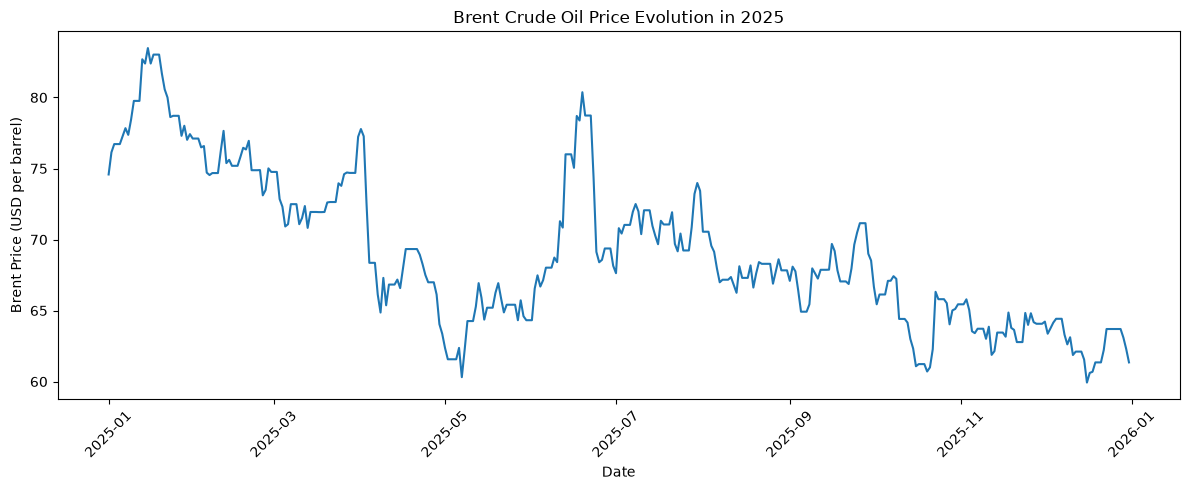

In [42]:
# Visualize the evolution of Brent crude oil prices during 2025
plt.figure(figsize=(12, 5))

plt.plot(
    brent_daily["Date"],
    brent_daily["Brent Price"]
)

plt.title("Brent Crude Oil Price Evolution in 2025")
plt.xlabel("Date")
plt.ylabel("Brent Price (USD per barrel)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

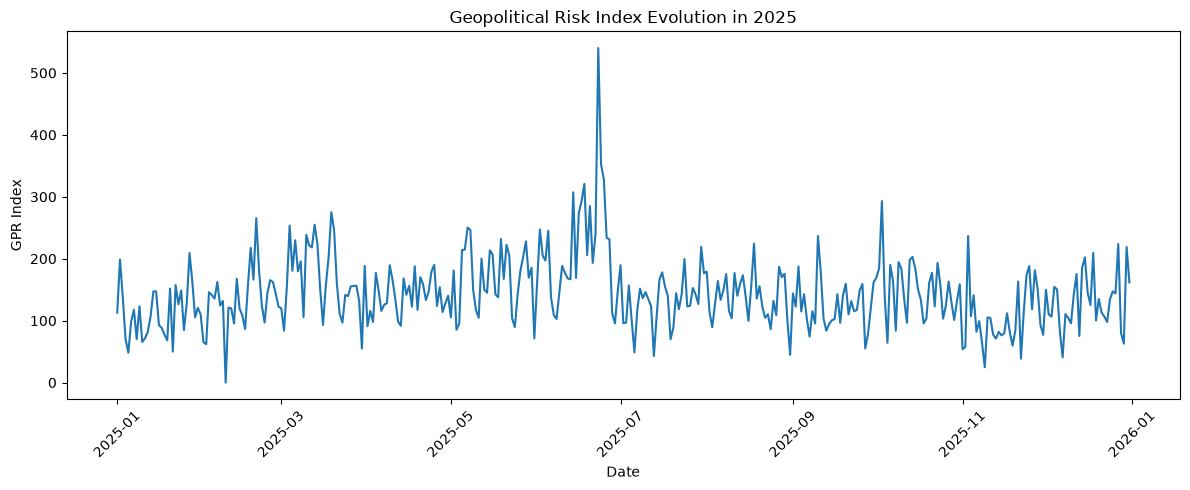

In [43]:
# Visualize daily geopolitical risk during 2025
plt.figure(figsize=(12, 5))

plt.plot(
    gpr_2025["Date"],
    gpr_2025["GPR"]
)

plt.title("Geopolitical Risk Index Evolution in 2025")
plt.xlabel("Date")
plt.ylabel("GPR Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Observations

- Brent crude oil prices show an overall downward trend during 2025, although several short-term increases are visible throughout the year.
- The Geopolitical Risk Index is substantially more volatile, with frequent daily fluctuations and several pronounced spikes, particularly around mid-year.
- These indicators capture different dimensions of the external environment: Brent reflects oil market conditions, while GPR reflects geopolitical uncertainty.
- Their potential predictive contribution to diesel prices will be evaluated during the modeling stage.

# 7. Feature Engineering

The objective of this stage is to transform the cleaned and enriched data into a modeling dataset suitable for predicting diesel prices.

Each observation represents a diesel price recorded at a specific fuel station and point in time. Features will capture temporal patterns, geographic characteristics, station characteristics, and external market conditions.

### Feature Selection Rationale

Based on the exploratory analysis and the project objective, the modeling dataset combines several categories of predictors:

- **Temporal information:** fuel prices showed clear variations throughout 2025. Date-based features will therefore be created to capture temporal patterns.
- **Geographic information:** diesel prices varied substantially across geographic areas. Latitude and longitude are retained as more precise geographic indicators than the approximate department variable derived from postal codes.
- **Station characteristics:** location type is retained because highway stations showed substantially higher diesel prices during EDA. The availability of a 24/7 payment terminal is also included as an additional station-level characteristic.
- **Oil market conditions:** Brent crude oil price is included because diesel prices may be associated with broader oil market conditions.
- **Geopolitical context:** the Geopolitical Risk Index is included to test whether periods of increased geopolitical uncertainty provide additional predictive information.

These variables are used as potential predictors rather than causal factors. Their actual predictive contribution will be assessed during model evaluation and feature importance analysis.

## 7.1 Building the Modeling Dataset

In [44]:
# Create the modeling dataset using diesel observations only
# The original prices dataframe remains unchanged
model_data = prices[
    prices["Fuel"] == "Gazole"
].copy()

# Create a normalized daily date key for external data merging
model_data["Day"] = model_data["Date"].dt.normalize()

print(model_data.shape)
display(model_data.head())

(1520476, 6)


,Station ID,Fuel ID,Fuel,Date,Price,Day
0,1000001,1.0,Gazole,2025-01-02 00:37:00,1.707,2025-01-02
1,1000001,1.0,Gazole,2025-01-02 07:56:00,1.707,2025-01-02
2,1000001,1.0,Gazole,2025-01-03 00:38:00,1.725,2025-01-03
3,1000001,1.0,Gazole,2025-01-07 00:37:00,1.705,2025-01-07
4,1000001,1.0,Gazole,2025-01-09 00:37:00,1.688,2025-01-09


In [45]:
# Add station-level characteristics to the modeling dataset
model_data = model_data.merge(
    stations[
        [
            "Station ID",
            "Location Type",
            "Latitude",
            "Longitude",
            "24/7 Payment Terminal"
        ]
    ],
    on="Station ID",
    how="left"
)

# Check that the merge did not duplicate or remove diesel observations
print("Shape:", model_data.shape)
print("\nMissing values:")
print(
    model_data[
        [
            "Location Type",
            "Latitude",
            "Longitude",
            "24/7 Payment Terminal"
        ]
    ].isna().sum()
)

display(model_data.head())

Shape: (1520476, 10)

Missing values:
Location Type            0
Latitude                 0
Longitude                0
24/7 Payment Terminal    0
dtype: int64


,Station ID,Fuel ID,Fuel,Date,Price,Day,Location Type,Latitude,Longitude,24/7 Payment Terminal
0,1000001,1.0,Gazole,2025-01-02 00:37:00,1.707,2025-01-02,R,46.201,5.198,0
1,1000001,1.0,Gazole,2025-01-02 07:56:00,1.707,2025-01-02,R,46.201,5.198,0
2,1000001,1.0,Gazole,2025-01-03 00:38:00,1.725,2025-01-03,R,46.201,5.198,0
3,1000001,1.0,Gazole,2025-01-07 00:37:00,1.705,2025-01-07,R,46.201,5.198,0
4,1000001,1.0,Gazole,2025-01-09 00:37:00,1.688,2025-01-09,R,46.201,5.198,0


In [46]:
# Prepare external datasets with the same daily merge key
brent_model = brent_daily.rename(columns={"Date": "Day"}).copy()
gpr_model = gpr_2025.rename(columns={"Date": "Day"}).copy()

# Add Brent crude oil prices to each diesel observation
model_data = model_data.merge(
    brent_model,
    on="Day",
    how="left"
)

# Add the Geopolitical Risk Index to each diesel observation
model_data = model_data.merge(
    gpr_model,
    on="Day",
    how="left"
)

# Validate the external data merges
print("Shape:", model_data.shape)
print("\nMissing values:")
print(model_data[["Brent Price", "GPR"]].isna().sum())

display(model_data.head())

Shape: (1520476, 12)

Missing values:
Brent Price    0
GPR            0
dtype: int64


,Station ID,Fuel ID,Fuel,Date,Price,Day,Location Type,Latitude,Longitude,24/7 Payment Terminal,Brent Price,GPR
0,1000001,1.0,Gazole,2025-01-02 00:37:00,1.707,2025-01-02,R,46.201,5.198,0,76.14,198.480301
1,1000001,1.0,Gazole,2025-01-02 07:56:00,1.707,2025-01-02,R,46.201,5.198,0,76.14,198.480301
2,1000001,1.0,Gazole,2025-01-03 00:38:00,1.725,2025-01-03,R,46.201,5.198,0,76.72,137.502808
3,1000001,1.0,Gazole,2025-01-07 00:37:00,1.705,2025-01-07,R,46.201,5.198,0,77.84,117.642593
4,1000001,1.0,Gazole,2025-01-09 00:37:00,1.688,2025-01-09,R,46.201,5.198,0,78.44,123.143776


### Prediction Strategy

The project follows a temporal prediction approach. The model will be trained on earlier observations from 2025 and evaluated on a later period that is kept unseen during training.

This chronological evaluation simulates a real-world scenario in which historical information is used to predict future diesel prices. Therefore, features must only contain information that would have been available before the prediction date.

The project is intentionally limited to 2025 data. The final months of 2025 will serve as the unseen future evaluation period.

## 7.2 Temporal Features

Several temporal features are extracted from the observation date to allow the models to capture seasonal and short-term patterns in diesel prices.

The selected features represent the month, week of the year, day of the week, and position of the observation within the year.

In [47]:
# Extract temporal features from the observation date
model_data["Month"] = model_data["Date"].dt.month
model_data["Week"] = model_data["Date"].dt.isocalendar().week.astype(int)
model_data["Day of Week"] = model_data["Date"].dt.dayofweek
model_data["Day of Year"] = model_data["Date"].dt.dayofyear

# Inspect the newly created temporal features
display(
    model_data[
        ["Date", "Month", "Week", "Day of Week", "Day of Year"]
    ].head()
)

,Date,Month,Week,Day of Week,Day of Year
0,2025-01-02 00:37:00,1,1,3,2
1,2025-01-02 07:56:00,1,1,3,2
2,2025-01-03 00:38:00,1,1,4,3
3,2025-01-07 00:37:00,1,2,1,7
4,2025-01-09 00:37:00,1,2,3,9


## 7.3 Lagged External Features

In [48]:
# Create one-day lagged external features
model_data = model_data.sort_values("Day").copy()

daily_external = (
    model_data[["Day", "Brent Price", "GPR"]]
    .drop_duplicates(subset="Day")
    .sort_values("Day")
    .copy()
)

daily_external["Brent Lag 1"] = daily_external["Brent Price"].shift(1)
daily_external["GPR Lag 1"] = daily_external["GPR"].shift(1)

# Add lagged external features back to the modeling dataset
model_data = model_data.merge(
    daily_external[["Day", "Brent Lag 1", "GPR Lag 1"]],
    on="Day",
    how="left"
)

# Inspect lagged features
display(
    model_data[
        ["Day", "Brent Price", "Brent Lag 1", "GPR", "GPR Lag 1"]
    ].head(10)
)

,Day,Brent Price,Brent Lag 1,GPR,GPR Lag 1
0,2025-01-01,74.58,NaN,112.811905,NaN
1,2025-01-01,74.58,NaN,112.811905,NaN
2,2025-01-01,74.58,NaN,112.811905,NaN
3,2025-01-01,74.58,NaN,112.811905,NaN
4,2025-01-01,74.58,NaN,112.811905,NaN
5,2025-01-01,74.58,NaN,112.811905,NaN
6,2025-01-01,74.58,NaN,112.811905,NaN
7,2025-01-01,74.58,NaN,112.811905,NaN
8,2025-01-01,74.58,NaN,112.811905,NaN
9,2025-01-01,74.58,NaN,112.811905,NaN


In [49]:
# Verify that the lag corresponds to the previous day's external values
display(
    model_data.loc[
        model_data["Day"].isin(
            pd.to_datetime(["2025-01-01", "2025-01-02", "2025-01-03"])
        ),
        ["Day", "Brent Price", "Brent Lag 1", "GPR", "GPR Lag 1"]
    ]
    .drop_duplicates()
    .sort_values("Day")
)

,Day,Brent Price,Brent Lag 1,GPR,GPR Lag 1
0,2025-01-01,74.58,NaN,112.811905,NaN
1999,2025-01-02,76.14,74.58,198.480301,112.811905
6206,2025-01-03,76.72,76.14,137.502808,198.480301


## 7.4 Feature Engineering Summary & Next Steps

The modeling dataset has now been constructed by combining diesel price observations with station characteristics, temporal information, and external indicators.

### Features currently prepared

- **Geographic features:** latitude and longitude
- **Station features:** location type and 24/7 payment terminal availability
- **Temporal features:** month, week of the year, day of the week, and day of the year
- **External market features:** Brent crude oil price and Geopolitical Risk Index
- **Lagged external features:** previous-day Brent price and previous-day GPR

One-day lags were introduced to ensure that external information used for prediction was already available before the prediction date and to reduce the risk of temporal data leakage.

### Next Steps

The next stage will prepare the data for machine learning. The target variable will be the diesel price (`Price`), and the dataset will be split chronologically so that the final period of 2025 remains unseen during training.

A Random Forest Regressor will first be used as a baseline model. XGBoost will then be used as the main model, followed by hyperparameter optimization and feature importance analysis.

# 8. Model Preparation

This section prepares the engineered dataset for machine learning.

The target variable is the diesel price (`Price`). Predictor variables are selected to represent temporal patterns, geographic and station characteristics, and external conditions available before the prediction date.

A chronological train-test split is used instead of a random split in order to simulate prediction on a future unseen period.

## 8.1 Feature and Target Selection

### Final Predictor Selection

The target variable is `Price`, representing the observed diesel price in euros per liter.

The final predictors include geographic coordinates, station characteristics, temporal features, and previous-day external indicators. Same-day Brent and GPR values are excluded from the predictor set to preserve the temporal prediction framework and reduce the risk of data leakage.

In [50]:
# Define the final predictor variables
features = [
    "Latitude",
    "Longitude",
    "Location Type",
    "24/7 Payment Terminal",
    "Month",
    "Week",
    "Day of Week",
    "Day of Year",
    "Brent Lag 1",
    "GPR Lag 1"
]

# Create the feature matrix and target vector
X = model_data[features].copy()
y = model_data["Price"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (1520476, 10)
y shape: (1520476,)


,Latitude,Longitude,Location Type,24/7 Payment Terminal,Month,Week,Day of Week,Day of Year,Brent Lag 1,GPR Lag 1
0,44.429000,4.712000,R,1,1,1,2,1,NaN,NaN
1,43.662000,4.633000,R,1,1,1,2,1,NaN,NaN
2,43.662000,4.633000,R,1,1,1,2,1,NaN,NaN
3,50.458280,2.975980,A,0,1,1,2,1,NaN,NaN
4,48.124794,-1.701432,R,0,1,1,2,1,NaN,NaN


## 8.2 Final Data Preparation

Before splitting the data, observations with unavailable lagged external indicators are removed. These observations correspond to the first day of the dataset, for which previous-day values cannot be calculated.

The categorical station location variable is then converted into a binary feature indicating whether the station is located on a highway.

In [51]:
# Keep only observations for which lagged predictors are available
model_ready = model_data.dropna(
    subset=["Brent Lag 1", "GPR Lag 1"]
).copy()

# Convert station location type into a numerical highway indicator
# A = highway station, R = non-highway station
model_ready["Is Highway"] = (
    model_ready["Location Type"] == "A"
).astype(int)

# Check the prepared modeling data
print("Shape before preparation:", model_data.shape)
print("Shape after preparation:", model_ready.shape)

print("\nHighway indicator:")
print(model_ready["Is Highway"].value_counts())

print("\nMissing values in modeling variables:")
print(
    model_ready[
        [
            "Price",
            "Latitude",
            "Longitude",
            "24/7 Payment Terminal",
            "Month",
            "Week",
            "Day of Week",
            "Day of Year",
            "Brent Lag 1",
            "GPR Lag 1",
            "Is Highway"
        ]
    ].isna().sum()
)

Shape before preparation: (1520476, 18)
Shape after preparation: (1518477, 19)

Highway indicator:
Is Highway
0    1403176
1     115301
Name: count, dtype: int64

Missing values in modeling variables:
Price                    0
Latitude                 0
Longitude                0
24/7 Payment Terminal    0
Month                    0
Week                     0
Day of Week              0
Day of Year              0
Brent Lag 1              0
GPR Lag 1                0
Is Highway               0
dtype: int64


## 8.3 Correlation Analysis

A correlation matrix is used to examine the relationships between the numerical predictors and the target variable (`Price`).

This analysis helps identify variables that are associated with diesel prices and detect strong correlations between predictors that may contain similar information.

In [52]:
# Select the numerical predictors and the target variable
correlation_features = [
    "Latitude",
    "Longitude",
    "24/7 Payment Terminal",
    "Is Highway",
    "Month",
    "Week",
    "Day of Week",
    "Day of Year",
    "Brent Lag 1",
    "GPR Lag 1",
    "Price"
]

# Calculate the correlation matrix
correlation_matrix = model_ready[correlation_features].corr()

display(correlation_matrix.round(2))

,Latitude,Longitude,24/7 Payment Terminal,Is Highway,Month,Week,Day of Week,Day of Year,Brent Lag 1,GPR Lag 1,Price
Latitude,1.00,-0.15,-0.03,-0.01,-0.00,-0.00,0.01,-0.00,0.00,-0.00,0.04
Longitude,-0.15,1.00,-0.04,0.04,-0.01,-0.01,0.00,-0.01,0.00,-0.00,0.13
24/7 Payment Terminal,-0.03,-0.04,1.00,-0.11,0.01,0.01,-0.03,0.01,-0.00,-0.00,-0.12
Is Highway,-0.01,0.04,-0.11,1.00,-0.00,-0.00,0.02,-0.00,-0.00,-0.01,0.47
Month,-0.00,-0.01,0.01,-0.00,1.00,0.95,-0.01,1.00,-0.76,-0.11,-0.17
Week,-0.00,-0.01,0.01,-0.00,0.95,1.00,0.00,0.95,-0.72,-0.09,-0.15
Day of Week,0.01,0.00,-0.03,0.02,-0.01,0.00,1.00,-0.01,-0.00,0.12,0.01
Day of Year,-0.00,-0.01,0.01,-0.00,1.00,0.95,-0.01,1.00,-0.76,-0.10,-0.16
Brent Lag 1,0.00,0.00,-0.00,-0.00,-0.76,-0.72,-0.00,-0.76,1.00,0.06,0.33
GPR Lag 1,-0.00,-0.00,-0.00,-0.01,-0.11,-0.09,0.12,-0.10,0.06,1.00,-0.09


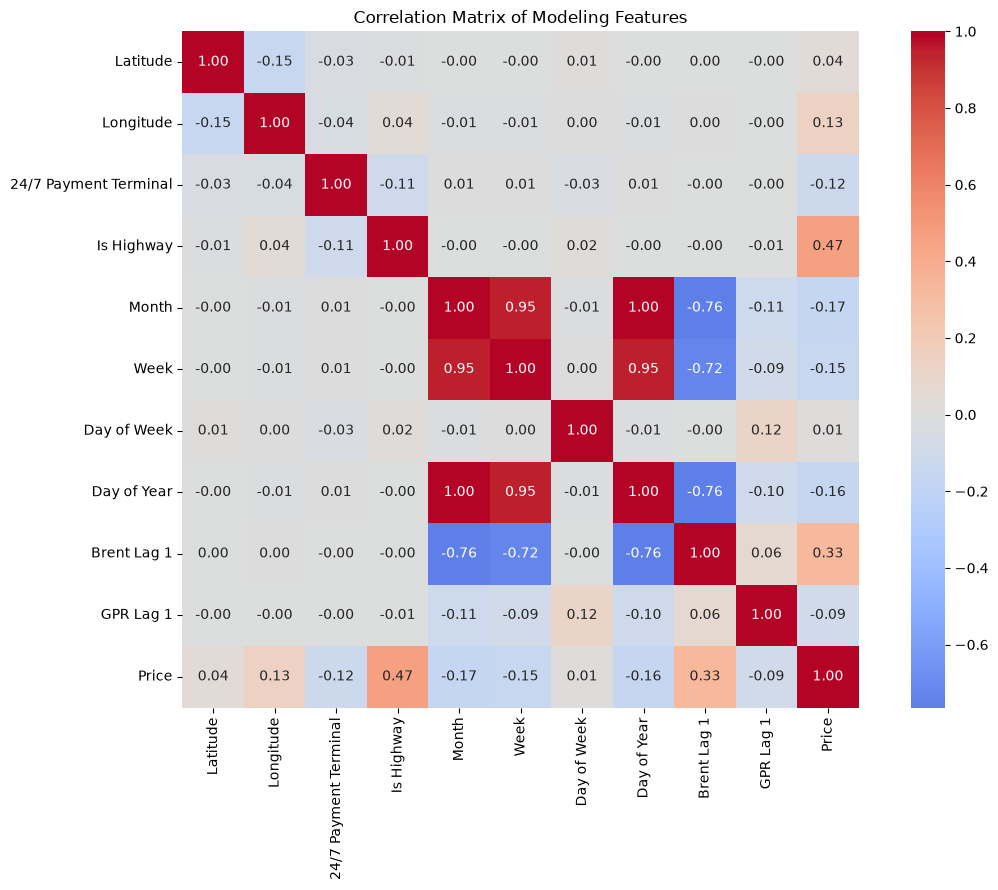

In [53]:
# Visualize the correlation matrix
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Modeling Features")
plt.tight_layout()
plt.show()

### Key Observations

- "Is Highway" shows the strongest positive correlation with diesel price (0.47), supporting the pattern already observed during EDA: highway stations tend to have higher prices.
- "Brent Lag 1" also shows a positive correlation with diesel price (0.33), suggesting that previous-day oil market conditions may provide useful information for predicting diesel prices.
- "Month", "Week", and "Day of Year" are highly correlated with each other (0.95 to 1.00) because they represent similar information about the position of an observation within the year.
- To reduce redundancy, "Day of Year" will be retained, while "Month" and "Week" will be removed from the final predictor set.
- The other predictors show weaker linear correlations with diesel price. However, they are kept because Random Forest and XGBoost can capture non-linear relationships and interactions that may not appear clearly in a correlation matrix.

Correlation shows association, not causation.

## 8.4 Chronological Train-Test Split

Because the objective is to predict diesel prices for a future unseen period, the dataset will be split chronologically rather than randomly.

Observations from January through October 2025 will be used for training, while November and December 2025 will be reserved as the final test period.

This approach prevents future observations from being used to train the model and provides a more realistic evaluation of its ability to generalize to future diesel prices.

#First, we sort the modeling dataset chronologically by date. This is important because this project follows a temporal prediction approach. We want the model to learn from past observations and then evaluate it on future observations.

In [57]:
# Separe train & test = Data from January to October are used to train the model,while November and December data remain completely unseen by the model.

# Sort the data chronologically
model_ready = model_ready.sort_values("Date").copy()

# Train: January to October 2025
train = model_ready[
    model_ready["Date"] < "2025-11-01"
].copy()

# Test: November and December 2025
test = model_ready[
    model_ready["Date"] >= "2025-11-01"
].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain period:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest period:")
print(test["Date"].min(), "to", test["Date"].max())

Train shape: (1253584, 19)
Test shape: (264893, 19)

Train period:
2025-01-02 00:00:00 to 2025-10-31 23:59:00

Test period:
2025-11-01 00:00:00 to 2025-12-31 23:59:00


In [58]:
# Define the target variable
target = "Price"

# Define the final predictor set after correlation analysis
features = [
    "Latitude",
    "Longitude",
    "24/7 Payment Terminal",
    "Is Highway",
    "Day of Week",
    "Day of Year",
    "Brent Lag 1",
    "GPR Lag 1"
]

# Create X and y for training
X_train = train[features].copy()
y_train = train[target].copy()

# Create X and y for testing
X_test = test[features].copy()
y_test = test[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1253584, 8)
y_train: (1253584,)
X_test: (264893, 8)
y_test: (264893,)


# 9. Baseline Model - Random Forest

A Random Forest regressor is used as a baseline model to provide a reference for the performance of the XGBoost model.

Because the training dataset is very large, the baseline model is trained on a reproducible sample of the training data to reduce computation time and memory usage.

## 9.1 Development and Validation Split

To avoid using the final test period during model development, the January-October training period is further divided into two periods.

- January to September: model development and training
- October: model validation and comparison
- November to December: final unseen test period

This chronological structure allows the models to be developed and compared without using information from the final test period.

In [61]:
# Development period: January to September 2025
development = train[
    train["Date"] < "2025-10-01"
].copy()

# Validation period: October 2025
validation = train[
    train["Date"] >= "2025-10-01"
].copy()

# Create predictors and target
X_dev = development[features].copy()
y_dev = development[target].copy()

X_val = validation[features].copy()
y_val = validation[target].copy()

print("Development:", X_dev.shape)
print("Validation:", X_val.shape)

print("\nDevelopment period:")
print(development["Date"].min(), "to", development["Date"].max())

print("\nValidation period:")
print(validation["Date"].min(), "to", validation["Date"].max())

Development: (1115731, 8)
Validation: (137853, 8)

Development period:
2025-01-02 00:00:00 to 2025-09-30 23:59:00

Validation period:
2025-10-01 00:00:00 to 2025-10-31 23:59:00


## 9.2 Random Forest Model Training

The Random Forest baseline is trained on the full development dataset from January to September.

A limited number of trees and tree depth are used to keep computation manageable.

In [76]:
# Create the Random Forest baseline model
rf_baseline = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    n_jobs=-1,
    random_state=17
)

# Train the Random Forest baseline on the full development dataset
rf_baseline.fit(X_dev, y_dev)

print("Random Forest training completed.")


Random Forest training completed.


## 9.3 Random Forest Baseline Evaluation

The Random Forest baseline is evaluated on the full October validation period using MAE, RMSE, and R².

In [77]:
# Predict diesel prices for the October validation period
rf_val_predictions = rf_baseline.predict(X_val)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_val, rf_val_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_predictions))
rf_r2 = r2_score(y_val, rf_val_predictions)

print(f"Random Forest MAE: {rf_mae:.4f} €/L")
print(f"Random Forest RMSE: {rf_rmse:.4f} €/L")
print(f"Random Forest R²: {rf_r2:.4f}")

Random Forest MAE: 0.0487 €/L
Random Forest RMSE: 0.0614 €/L
Random Forest R²: 0.5087


### Baseline Results

The Random Forest baseline achieved:

- MAE: 0.0487 €/L
- RMSE: 0.0614 €/L
- R²: 0.5087

The MAE indicates that the model's predictions differ from the actual diesel prices by approximately 4.9 cents per liter on average.

The higher RMSE (6.14 cents/L) indicates that some predictions have larger errors.

The R² score shows that the model explains approximately 50.9% of the variation in diesel prices during the October validation period.

These results provide a baseline for comparison with the XGBoost model.

# 10. XGBoost Model

XGBoost is used as the main predictive model for this project.

An initial XGBoost model is first trained before hyperparameter tuning. Its performance will be evaluated on the October validation period and compared with the Random Forest baseline.

## 10.1 Initial XGBoost Model

An initial XGBoost regressor is trained using the development period before hyperparameter tuning.

The model is evaluated on the October validation period to establish its initial performance and compare it with the Random Forest baseline.

In [72]:
# Create the initial XGBoost model
xgb_initial = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    tree_method="hist",
    random_state=17,
    n_jobs=-1
)

In [73]:
# Create a reproducible sample for the initial XGBoost model
xgb_sample_size = 100_000

xgb_sample_index = X_dev.sample(
    n=xgb_sample_size,
    random_state=17
).index

X_dev_xgb = X_dev.loc[xgb_sample_index]
y_dev_xgb = y_dev.loc[xgb_sample_index]

print("XGBoost training sample:", X_dev_xgb.shape)

XGBoost training sample: (100000, 8)


## 10.2 Initial XGBoost Model Training

The initial XGBoost model is trained on the full development dataset from January to September.

In [79]:
# Train the initial XGBoost model on the full development dataset
xgb_initial.fit(X_dev, y_dev)

print("Initial XGBoost training completed.")

Initial XGBoost training completed.


## 10.3 Initial XGBoost Evaluation

The initial XGBoost model is evaluated on the full October validation period using the same metrics as the Random Forest baseline.

In [80]:
# Predict diesel prices for the October validation period
xgb_val_predictions = xgb_initial.predict(X_val)

# Calculate evaluation metrics
xgb_mae = mean_absolute_error(y_val, xgb_val_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_predictions))
xgb_r2 = r2_score(y_val, xgb_val_predictions)

print(f"XGBoost MAE: {xgb_mae:.4f} €/L")
print(f"XGBoost RMSE: {xgb_rmse:.4f} €/L")
print(f"XGBoost R²: {xgb_r2:.4f}")

XGBoost MAE: 0.0380 €/L
XGBoost RMSE: 0.0502 €/L
XGBoost R²: 0.6717


### Initial XGBoost Results

The initial XGBoost model achieved:

- MAE: 0.0380 €/L
- RMSE: 0.0502 €/L
- R²: 0.6717

The model's predictions differ from the actual diesel prices by approximately 3.8 cents per liter on average.

Compared with the Random Forest baseline, the initial XGBoost model reduces the MAE from 4.9 to 3.8 cents per liter and increases the R² from 0.5087 to 0.6717.

The initial XGBoost model therefore performs better than the Random Forest baseline on the October validation period. Hyperparameter tuning will now be used to investigate whether its predictive performance can be further improved.

# 11. XGBoost Hyperparameter Tuning

The initial XGBoost model already outperformed the Random Forest baseline on the October validation period.

Hyperparameter tuning is now performed in three stages:

1. Random Search
2. Grid Search
3. Manual Search

The objective is to improve the XGBoost model while keeping the October period for model validation and the November-December period untouched for final evaluation.

## 11.1 Random Search

Random Search is first used to explore different combinations of XGBoost hyperparameters.

Following the tuning approach used in the course, five XGBoost hyperparameters are explored: the number of trees, learning rate, row subsampling, feature subsampling and L2 regularization.

Because this project uses chronological data, a predefined validation split is used instead of standard cross-validation. January to September observations are used for training, while October is used for validation. November and December remain untouched for the final model evaluation.

In [82]:
# Combine development and validation data for hyperparameter tuning
X_tuning = pd.concat([X_dev, X_val])
y_tuning = pd.concat([y_dev, y_val])

# January-September observations are used for training (-1)
# October observations are used for validation (0)
test_fold = np.concatenate([
    np.full(len(X_dev), -1),
    np.zeros(len(X_val))
])

# Create the predefined chronological validation split
predefined_split = PredefinedSplit(test_fold=test_fold)

print("Tuning dataset:", X_tuning.shape)
print("Training observations:", len(X_dev))
print("Validation observations:", len(X_val))

Tuning dataset: (1253584, 8)
Training observations: 1115731
Validation observations: 137853


### 11.2 Random Search Training

The Random Search explores 10 randomly selected combinations of XGBoost hyperparameters.

The search space follows the hyperparameters used in the course: `n_estimators`, `learning_rate`, `subsample`, `colsample_bytree` and `reg_lambda`.

In [83]:
# Define the XGBoost hyperparameter search space
xgb_param_grid = {
    "n_estimators": [300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1, 3, 10, 20]
}

# Create the XGBoost model
xgb_random = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=17,
    n_jobs=1
)

# Perform Random Search using the chronological validation split
random_search = RandomizedSearchCV(
    estimator=xgb_random,
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=predefined_split,
    scoring="neg_mean_absolute_error",
    random_state=17,
    n_jobs=-1
)

# Train and evaluate the 10 randomly selected combinations
random_search.fit(X_tuning, y_tuning)

print("Random Search completed.")

Random Search completed.


### 11.3 Random Search Results

The best hyperparameter combination identified by Random Search is extracted together with its validation MAE.

In [84]:
# Display the best hyperparameter combination
print("Best parameters:")
print(random_search.best_params_)

# Convert the negative MAE back to a positive value
random_search_mae = -random_search.best_score_

print(f"\nBest Random Search validation MAE: {random_search_mae:.4f} €/L")

Best parameters:
{'subsample': 1.0, 'reg_lambda': 3, 'n_estimators': 1000, 'learning_rate': 0.1, 'colsample_bytree': 0.6}

Best Random Search validation MAE: 0.0383 €/L


### 11.4 Grid Search

Based on the best combination identified by Random Search, Grid Search is used to explore a narrower range of hyperparameter values around the most promising region.

The same predefined chronological validation strategy is maintained to avoid temporal leakage.

In [85]:
# Define a narrower grid around the best Random Search parameters
xgb_grid = {
    "n_estimators": [800, 1000],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.6],
    "reg_lambda": [3, 5]
}

# Create the XGBoost model
xgb_grid_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=17,
    n_jobs=1
)

# Perform Grid Search using the same chronological validation split
grid_search = GridSearchCV(
    estimator=xgb_grid_model,
    param_grid=xgb_grid,
    cv=predefined_split,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

# Evaluate all parameter combinations
grid_search.fit(X_tuning, y_tuning)

print("Grid Search completed.")

Grid Search completed.


### 11.5 Grid Search Results

The best hyperparameter combination identified by Grid Search is extracted together with its validation MAE.

In [86]:
# Display the best hyperparameter combination
print("Best parameters:")
print(grid_search.best_params_)

# Convert the negative MAE back to a positive value
grid_search_mae = -grid_search.best_score_

print(f"\nBest Grid Search validation MAE: {grid_search_mae:.4f} €/L")

Best parameters:
{'colsample_bytree': 0.6, 'learning_rate': 0.1, 'n_estimators': 1000, 'reg_lambda': 3, 'subsample': 0.9}

Best Grid Search validation MAE: 0.0380 €/L


### 11.6 Manual Search

After Random Search and Grid Search, a small number of parameter combinations are tested manually.

The objective is to investigate values around the best Grid Search configuration, particularly parameters that reached the boundaries of the previous search space, while keeping the same chronological validation strategy.

### 11.7 Manual Search Training

Four targeted XGBoost configurations are evaluated manually using the same chronological training and validation periods.

The best Grid Search configuration is used as the reference. Individual parameters are then adjusted to investigate whether slightly more trees, a lower feature sampling ratio, or stronger regularization can improve validation performance.

In [87]:
# Define targeted configurations around the best Grid Search result
manual_configs = [
    {
        "name": "Grid Search Best",
        "n_estimators": 1000,
        "learning_rate": 0.1,
        "subsample": 0.9,
        "colsample_bytree": 0.6,
        "reg_lambda": 3
    },
    {
        "name": "More Trees",
        "n_estimators": 1200,
        "learning_rate": 0.1,
        "subsample": 0.9,
        "colsample_bytree": 0.6,
        "reg_lambda": 3
    },
    {
        "name": "Lower Feature Sampling",
        "n_estimators": 1000,
        "learning_rate": 0.1,
        "subsample": 0.9,
        "colsample_bytree": 0.5,
        "reg_lambda": 3
    },
    {
        "name": "Stronger Regularization",
        "n_estimators": 1000,
        "learning_rate": 0.1,
        "subsample": 0.9,
        "colsample_bytree": 0.6,
        "reg_lambda": 5
    }
]

In [88]:
# Store the results of each manual configuration
manual_results = []

# Train and evaluate each configuration
for config in manual_configs:

    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_estimators=config["n_estimators"],
        learning_rate=config["learning_rate"],
        subsample=config["subsample"],
        colsample_bytree=config["colsample_bytree"],
        reg_lambda=config["reg_lambda"],
        random_state=17,
        n_jobs=-1
    )

    # Train on the development period
    model.fit(X_dev, y_dev)

    # Predict the October validation period
    predictions = model.predict(X_val)

    # Calculate validation MAE
    mae = mean_absolute_error(y_val, predictions)

    manual_results.append({
        "Configuration": config["name"],
        "MAE": mae
    })

# Display the results
manual_results_df = pd.DataFrame(manual_results)
manual_results_df = manual_results_df.sort_values("MAE")

manual_results_df

,Configuration,MAE
1,More Trees,0.037380
0,Grid Search Best,0.038214
2,Lower Feature Sampling,0.038214
3,Stronger Regularization,0.038514


### 11.8 Manual Search Results

The manual search showed that increasing the number of trees from 1000 to 1200 produced the lowest validation MAE.

The best manual configuration achieved a MAE of approximately 0.0374 €/L, corresponding to an average prediction error of about 3.7 cents per liter.

Reducing feature sampling did not improve performance, while stronger L2 regularization slightly increased the validation error.

The final selected configuration is therefore:

- "n_estimators" = 1200
- "learning_rate" = 0.1
- "subsample" = 0.9
- "colsample_bytree" = 0.6
- "reg_lambda" = 3

# 12. Final Model Evaluation

After hyperparameter tuning, the selected XGBoost configuration is retrained using all available data from January to October.

The final model is then evaluated on the November-December test period, which has remained completely unseen during model development and hyperparameter tuning.

In [89]:
# Create the final XGBoost model using the selected hyperparameters
final_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1200,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.6,
    reg_lambda=3,
    tree_method="hist",
    random_state=17,
    n_jobs=-1
)

# Train the final model on the complete January-October training period
final_xgb.fit(X_train, y_train)

print("Final XGBoost training completed.")

Final XGBoost training completed.


## 12.1 Final Test Evaluation

The final XGBoost model is evaluated on the November-December test period.

This period was kept completely separate from model training and hyperparameter tuning, providing an unbiased evaluation of the model's ability to predict future diesel prices.

In [90]:
# Predict diesel prices for the unseen November-December test period
final_predictions = final_xgb.predict(X_test)

# Calculate final evaluation metrics
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print(f"Final Test MAE: {final_mae:.4f} €/L")
print(f"Final Test RMSE: {final_rmse:.4f} €/L")
print(f"Final Test R²: {final_r2:.4f}")

Final Test MAE: 0.0507 €/L
Final Test RMSE: 0.0639 €/L
Final Test R²: 0.5957


In [91]:
# Evaluate the final model on the training period to check for overfitting
train_predictions = final_xgb.predict(X_train)

train_mae = mean_absolute_error(y_train, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
train_r2 = r2_score(y_train, train_predictions)

print(f"Training MAE: {train_mae:.4f} €/L")
print(f"Training RMSE: {train_rmse:.4f} €/L")
print(f"Training R²: {train_r2:.4f}")

Training MAE: 0.0303 €/L
Training RMSE: 0.0398 €/L
Training R²: 0.8347


## 12.2 Final Model Results

The final XGBoost model achieved:

- Test MAE: 0.0507 €/L
- Test RMSE: 0.0639 €/L
- Test R²: 0.5957

On the unseen November-December period, the model predicts diesel prices with an average error of approximately 5.1 cents per liter.

The training performance was stronger, with a MAE of 0.0303 €/L and an R² of 0.8347, compared with a test MAE of 0.0507 €/L and an R² of 0.5957.

This train-test performance gap indicates some overfitting. However, the model still explains approximately 59.6% of the variation in diesel prices during the unseen future period.

The lower performance on November-December may also reflect changes in price patterns that are not fully captured by the available features.

In [92]:
# Calculate monthly median diesel prices
monthly_test_analysis = (
    model_ready
    .groupby("Month")["Price"]
    .median()
    .reset_index()
)

monthly_test_analysis

,Month,Price
0,1,1.709
1,2,1.693
2,3,1.645
3,4,1.585
4,5,1.546
5,6,1.615
6,7,1.631
7,8,1.599
8,9,1.609
9,10,1.602


The train-test performance gap suggests some overfitting. However, the test period also shows a marked change in diesel price dynamics: the monthly median increased from 1.602 €/L in October to 1.679 €/L in November, before decreasing to 1.599 €/L in December.

Therefore, the lower test performance may reflect both model overfitting and changing price patterns during the unseen future period.

# 13. Feature Importance

Feature importance is extracted from the final XGBoost model to identify which predictors contributed most to the model's predictions.

These importance scores represent predictive contribution within the model and should not be interpreted as causal effects.

In [93]:
# Extract feature importance from the final XGBoost model
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": final_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
3,Is Highway,0.530976
5,Day of Year,0.125668
6,Brent Lag 1,0.103811
1,Longitude,0.094883
0,Latitude,0.090956
2,24/7 Payment Terminal,0.029908
7,GPR Lag 1,0.017066
4,Day of Week,0.006733


## 13.1 Feature Importance Visualization

The relative importance of each predictor is visualized to better understand which features contributed most to the final XGBoost predictions.

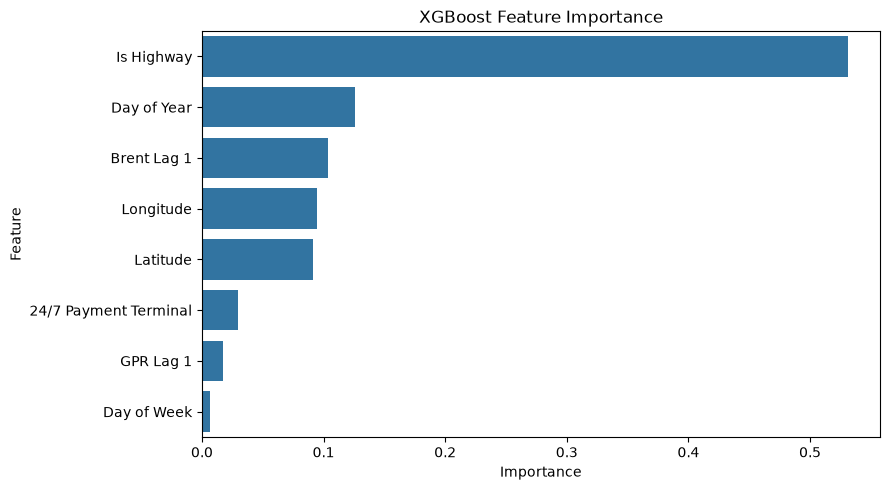

In [94]:
# Visualize feature importance
plt.figure(figsize=(9, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 13.2 Feature Importance Interpretation

Station location is the strongest predictor in the model. "Is Highway" represents approximately 53% of the total feature importance, confirming the strong price differences between highway and non-highway stations already observed during EDA.

Temporal information is also important, with "Day of Year" being the second most influential feature.

"Brent Lag 1" is the third most important predictor, suggesting that recent changes in the international oil market contribute to diesel price predictions.

Geographic location also plays an important role, with both longitude and latitude contributing substantially to the model.

"GPR Lag 1" and "Day of Week" have relatively limited predictive importance.

These results represent predictive importance within the XGBoost model and should not be interpreted as causal relationships.

# 14. Conclusion

This project investigated whether XGBoost could predict diesel prices in France using historical, geographical, station-level and external market features.

The final model achieved a MAE of 0.0507 €/L, corresponding to an average prediction error of approximately 5.1 cents per liter on the unseen November-December period. The model obtained an R² of 0.5957, explaining approximately 59.6% of the variation in diesel prices during the test period.

XGBoost outperformed the Random Forest baseline during model development. Hyperparameter tuning through Random Search, Grid Search and Manual Search further improved validation performance, with the best configuration reaching a MAE of approximately 3.7 cents per liter on October data.

Feature importance showed that station location was particularly influential. "Is Highway" was the strongest predictor, followed by "Day of Year", "Brent Lag 1" and geographic coordinates. This is consistent with the EDA, which showed substantial price differences between highway and non-highway stations.

The difference between training and test performance suggests some overfitting. However, the test period also contained marked changes in diesel price dynamics, including an increase in the monthly median from 1.602 €/L in October to 1.679 €/L in November, followed by a decrease to 1.599 €/L in December.

Future improvements could include additional lagged market variables, station-level historical price features, multi-year data and more advanced time-aware validation strategies.